## 1. Imports y Configuracion


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Configuramos la paleta de Seaborn predeterminada a "Set1" (que tiene rojo y azul)
sns.set_theme(style='ticks', context='paper', font_scale=1.2, palette='Set1')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Carga de Datos


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

trans = pd.read_csv('/content/drive/MyDrive/Datasets/Final Project/HI-Small_Trans.csv')
accounts = pd.read_csv('/content/drive/MyDrive/Datasets/Final Project/HI-Small_accounts.csv')

Mounted at /content/drive


## 3. Función de Limpieza

### Explicación de Limpieza de Datos (`clean_data`)
*   **Eliminación de duplicados:** Se identifican y descartan filas completamente idénticas.
*   **Alineación temporal:** Se convierte la columna `Timestamp` a formato `datetime` y se ordenan los registros cronológicamente (vital para evitar fuga de información referenciando cosas del futuro).
*   **Cruce de información:** Se combina el dataset de transacciones con la tabla de cuentas para traernos el "Entity Name" de origen y destino.
*   **Extracción de entidades:** Usando expresiones regulares (`regex`), se aísla el tipo de entidad comercial/personal estructurando los nulos a `'Unknown'`.

In [ ]:
def clean_data(trans_df: pd.DataFrame,
               accounts_df: pd.DataFrame) -> pd.DataFrame:

    df  = trans_df.copy()
    acc = accounts_df.drop_duplicates(subset='Account Number', keep='first').copy()

    # --- Duplicados exactos ---
    n_before = len(df)
    df = df.drop_duplicates()
    n_dropped = n_before - len(df)

    # --- Timestamp a datetime y orden cronologico ---
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values('Timestamp').reset_index(drop=True)

    # --- Merge con tabla de cuentas (origen y destino) ---
    df = df.merge(
        acc[['Account Number', 'Entity Name']].rename(
            columns={'Account Number': 'Account',
                     'Entity Name'  : 'From Entity Name'}),
        on='Account', how='left'
    )
    df = df.merge(
        acc[['Account Number', 'Entity Name']].rename(
            columns={'Account Number': 'Account.1',
                     'Entity Name'  : 'To Entity Name'}),
        on='Account.1', how='left'
    )

    # --- Extraccion del tipo de entidad ---
    df['From Entity Type'] = (
        df['From Entity Name'].str.extract(r'^([\w\s]+?)\s*#').fillna('Unknown')
    )
    df['To Entity Type'] = (
        df['To Entity Name'].str.extract(r'^([\w\s]+?)\s*#').fillna('Unknown')
    )

    return df

In [ ]:
df = clean_data(trans, accounts)
df.head(3)

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,From Entity Name,To Entity Name,From Entity Type,To Entity Type
0,2022-09-01,32282,801B64CE0,32282,801B64CE0,29294.0300,US Dollar,29294.0300,US Dollar,Reinvestment,0,Sole Proprietorship #4172,Sole Proprietorship #4172,Sole Proprietorship,Sole Proprietorship
1,2022-09-01,212818,804B1DF50,212818,804B1DF50,538528.5300,Rupee,538528.5300,Rupee,Reinvestment,0,Partnership #32618,Partnership #32618,Partnership,Partnership
2,2022-09-01,16927,8062913A0,28,806291440,96718657.0000,Ruble,96718657.0000,Ruble,ACH,0,Partnership #34005,Partnership #33832,Partnership,Partnership


## 4. Pipeline de Ingeniería de Características

### Explicación del Pipeline Base (`build_features`)

*   **A. Características Temporales:** Captura la naturaleza cíclica del tiempo usando transformaciones de Seno y Coseno para horas y días, junto con marcadores binarios (Horario Nocturno o Fin de Semana).
*   **B. Características de Monto:** Las cantidades se suavizan con transformaciones logarítmicas (`np.log1p`) para manejar montos extremos (outliers). Se extraen proporciones transaccionales ("Ratio" de lo enviado vs. recibido).
*   **C. Indicadores de Riesgo Simples:** Distancias sospechosas iniciales como `Self Transaction` (cuentas enviándose a sí mismas), el involucramiento del mismo banco, o monedas (`Currency Mismatch`).
*   **D. Historial Transaccional (Cuentas):** Funciones móviles pre-procesadas con `.expanding().shift(1)` para extraer la Media, Desviación Estándar y **Z-Scores** pasados para evaluar si el monto presente tiene sentido según su histórico.
*   **E. Grafo Básico:** Rastreo histórico rápido de cuántos receptores (o emisores) únicos ha tocado un perfil con anterioridad.
*   **F. Codificación:** Discretización de entidades (One-Hot Encoder y variables tipo etiqueta conjuntas como "Entity Combo").

In [ ]:
def _expanding_agg(df: pd.DataFrame,
                   group_col: str,
                   value_col: str,
                   agg_funcs: dict,
                   prefix: str) -> pd.DataFrame:

    grp = df.groupby(group_col)[value_col]
    for suffix, func in agg_funcs.items():
        df[f'{prefix}_{suffix}'] = (
            grp.expanding().agg(func)
               .shift(1)
               .reset_index(level=0, drop=True)
        )
    return df


def _expanding_nunique_shift(df: pd.DataFrame,
                              group_col: str,
                              target_col: str,
                              new_col: str) -> pd.DataFrame:
    """
    Cuenta contrapartes unicas acumuladas por cuenta usando shift(1).
    Implementacion con diccionario de conjuntos para eficiencia O(n).
    """
    seen   = {}
    result = []
    for g, t in zip(df[group_col], df[target_col]):
        seen.setdefault(g, set())
        result.append(len(seen[g]))   # antes de agregar la actual
        seen[g].add(t)
    df[new_col] = result
    return df

In [ ]:
def build_features(df: pd.DataFrame) -> dict:

    out = df.copy()

    # FEATURES TEMPORALES

    out['Hour']    = out['Timestamp'].dt.hour
    out['DayNum']  = out['Timestamp'].dt.dayofweek   # 0=Lun, 6=Dom

    out['Hour_sin']  = np.sin(2 * np.pi * out['Hour']   / 24)
    out['Hour_cos']  = np.cos(2 * np.pi * out['Hour']   / 24)
    out['Day_sin']   = np.sin(2 * np.pi * out['DayNum'] / 7)
    out['Day_cos']   = np.cos(2 * np.pi * out['DayNum'] / 7)

    # Binarios interpretables
    out['Is_Night']   = out['Hour'].apply(lambda h: int(h >= 22 or h < 6))
    out['Is_Weekend'] = (out['DayNum'] >= 5).astype(int)

    # FEATURES DE MONTO
    out['Log Amount Paid']     = np.log1p(out['Amount Paid'])
    out['Log Amount Received'] = np.log1p(out['Amount Received'])

    # Diferencia en escala log -> robusta ante outliers
    out['Log Amount Diff']  = np.log1p(np.abs(out['Amount Paid'] - out['Amount Received']))

    # Ratio en escala log: log(Paid) - log(Received) = log(Paid/Received)
    # Evita los valores extremos del ratio lineal cuando Received ~ 0
    out['Log Amount Ratio'] = (
        np.log1p(out['Amount Paid']) - np.log1p(out['Amount Received'] + 1e-8)
    )

    out['Currency Mismatch'] = (out['Payment Currency'] != out['Receiving Currency']).astype(int)
    out['Self Transaction']  = (out['Account'] == out['Account.1']).astype(int)
    out['Same Bank']         = (out['From Bank'] == out['To Bank']).astype(int)

    # AGREGACIONES HISTORICAS POR CUENTA  (expanding + shift)

    agg_funcs = {'mean': 'mean', 'std': 'std', 'count': 'count'}

    out = _expanding_agg(out, 'Account',   'Amount Paid',      agg_funcs, 'From_Hist')
    out = _expanding_agg(out, 'Account.1', 'Amount Received',  agg_funcs, 'To_Hist')

    # Cold-start: primera transaccion de cada cuenta -> rellenar con media global
    gm_paid = out['Amount Paid'].mean();     gs_paid = out['Amount Paid'].std()
    gm_recv = out['Amount Received'].mean(); gs_recv = out['Amount Received'].std()

    out['From_Hist_mean']  = out['From_Hist_mean'].fillna(gm_paid)
    out['From_Hist_std']   = out['From_Hist_std'].fillna(gs_paid)
    out['From_Hist_count'] = out['From_Hist_count'].fillna(0)
    out['To_Hist_mean']    = out['To_Hist_mean'].fillna(gm_recv)
    out['To_Hist_std']     = out['To_Hist_std'].fillna(gs_recv)
    out['To_Hist_count']   = out['To_Hist_count'].fillna(0)

    # Z-score del monto vs historico de esa cuenta (clippeado a [-10, 10])
    out['Amount_Zscore_From'] = (
        (out['Amount Paid'] - out['From_Hist_mean']) / (out['From_Hist_std'] + 1e-8)
    ).clip(-10, 10)

    out['Amount_Zscore_To'] = (
        (out['Amount Received'] - out['To_Hist_mean']) / (out['To_Hist_std'] + 1e-8)
    ).clip(-10, 10)

    out['Log_From_Hist_count'] = np.log1p(out['From_Hist_count'])
    out['Log_To_Hist_count']   = np.log1p(out['To_Hist_count'])


    # FEATURES DE GRAFO
    out = _expanding_nunique_shift(out, 'Account',   'Account.1', 'From_Unique_Dest')
    out = _expanding_nunique_shift(out, 'Account.1', 'Account',   'To_Unique_Src')

    out['Log_From_Unique_Dest'] = np.log1p(out['From_Unique_Dest'])
    out['Log_To_Unique_Src']    = np.log1p(out['To_Unique_Src'])

    # Frecuencia historica del par exacto (Account -> Account.1)
    pair_count, pair_freq = {}, []
    for pair in (out['Account'].astype(str) + '_' + out['Account.1'].astype(str)):
        pair_freq.append(pair_count.get(pair, 0))
        pair_count[pair] = pair_count.get(pair, 0) + 1
    out['Log_Pair_Freq'] = np.log1p(pair_freq)

    # ENCODING DE ENTIDADES
    out['Entity Combo'] = out['From Entity Type'] + '_TO_' + out['To Entity Type']

    le_from  = LabelEncoder().fit(out['From Entity Type'].astype(str))
    le_to    = LabelEncoder().fit(out['To Entity Type'].astype(str))
    le_combo = LabelEncoder().fit(out['Entity Combo'].astype(str))

    out['From_Entity_LE']  = le_from.transform(out['From Entity Type'].astype(str))
    out['To_Entity_LE']    = le_to.transform(out['To Entity Type'].astype(str))
    out['Entity_Combo_LE'] = le_combo.transform(out['Entity Combo'].astype(str))

    # ONE-HOT ENCODING
    cat_cols = ['Payment Format', 'Payment Currency']
    out = pd.get_dummies(out, columns=cat_cols,
                         prefix=['PayFmt', 'PayCur'],
                         sparse=True, dtype='uint8')
    ohe_cols = [c for c in out.columns if c.startswith(('PayFmt_', 'PayCur_'))]

    # SELECCION FINAL

    FEATURES_BASE = [
        'Log Amount Paid', 'Log Amount Received',
        'Log Amount Diff', 'Log Amount Ratio',
        'Hour_sin', 'Hour_cos', 'Day_sin', 'Day_cos',
        'Is_Night', 'Is_Weekend',
        'Currency Mismatch', 'Self Transaction', 'Same Bank',
        'Amount_Zscore_From', 'Log_From_Hist_count',
        'Amount_Zscore_To',   'Log_To_Hist_count',
        'Log_From_Unique_Dest', 'Log_To_Unique_Src',
        'Log_Pair_Freq',
        'From_Entity_LE', 'To_Entity_LE', 'Entity_Combo_LE',
    ]
    FEATURES_TE  = ['From Entity Type', 'To Entity Type', 'Entity Combo']
    FEATURES_ALL = FEATURES_BASE + ohe_cols

    X = out[FEATURES_ALL]
    y = out['Is Laundering']

    return {
        'X'             : X,
        'y'             : y,
        'feature_names' : FEATURES_ALL,
        'features_base' : FEATURES_BASE,
        'features_ohe'  : ohe_cols,
        'features_te'   : FEATURES_TE,
        'label_encoders': {'from': le_from, 'to': le_to, 'combo': le_combo},
        'df_full'       : out,
    }

In [ ]:
pipeline_output = build_features(df)

X = pipeline_output['X']
y = pipeline_output['y']

# 5. Advanced Features (Características de Grafo y Ciclos)

En este notebook avanzado, llevamos la ingeniería de características un nivel más allá modelando la topología de la red transaccional para detectar estructuras complejas típicas en métodos de lavado (p. ej., Smurfing o fraccionamiento):

### A. Estructuras Topológicas y Flujo (`build_graph_features_advanced`)
*   **2-Ciclos (`Has_2Cycle`):** Verificación binaria que detecta transferencias recíprocas directas (A $\rightarrow$ B y de vuelta B $\rightarrow$ A).
*   **Scatter-Gather y Gather-Scatter (`Log_SG_Count`, `Log_GS_Count`):** Cuenta la cantidad de nodos intermediarios a través de los cuales fluye dinero para ocultar su origen ("Dispersar y Recolectar").
*   **Grado y Fan-Ratio:** Extrae el volumen histórico total del emisor/receptor, y la fracción o tasa de diversificación (`Fan_Ratio`); es decir, ¿envía su dinero a un solo destinatario el 100% de las veces, o es diversificado?
*   **Velocidad Transaccional 7 Días (`_Vel_7d`):** Medidor de la aceleración móvil transaccional en la ventana inmediata de los pasados 7 días.
*   **Z-Score exclusivo por Parejas (`Pair_Amt_Zscore`):** A diferencia de medir una cuenta, verifica cuán atípico es un pago al ser analizado estrictamente de cara al historial *exclusivo* que esa cuenta origen ha tenido *contra* esa cuenta destino.

### B. Ciclos Complejos y Bicliques (`build_cycle_biclique_features`)
Las mafias rara vez conectan cuentas directamente; este bloque implementa álgebra de matrices dispersas rápidos (Sparse Matrix Multiplication) para deducir patrones cerrados en las relaciones históricas generalizadas:
*   **Triángulos Dirigidos y No Dirigidos (`DirC3`, `UndC3`):** Cadenas transaccionales que cierran un triángulo (A $\rightarrow$ B $\rightarrow$ C $\rightarrow$ A), un fenómeno atípico para transacciones orgánicas pero muy visto en rebote de fondos rápidos.
*   **Ciclos de Longitud 4 (`DirC4`):** Anillos de la red consistentes de 4 pasos (e.g., A $\rightarrow$ B $\rightarrow$ C $\rightarrow$ D $\rightarrow$ A).
*   **Estructuras Bicliques $K_{2,2}$ (`Has_Bic`):** Patrones colaborativos donde múltiples co-emisores envían dinero, de manera compartida, hacia múltiples destinatarios exactos. Es la firma más fuerte para identificar clústeres organizados o mulas de cuentas.

In [ ]:
import time
import numpy as np
import pandas as pd


# ─────────────────────────────────────────────────────────────────────────────
# UTILIDADES INTERNAS
# ─────────────────────────────────────────────────────────────────────────────

def _timed(msg: str):
    """Context manager de timing para bloques de código."""
    class _T:
        def __enter__(self):
            print(f"   {msg}...", end=" ", flush=True)
            self.t0 = time.time()
        def __exit__(self, *_):
            print(f"✓ {time.time() - self.t0:.1f}s")
    return _T()


def _build_adjacency(df: pd.DataFrame):
    """
    Construye estructuras de grafo a partir del DataFrame completo.
    Retorna dicts de sets para vecinos de salida e entrada.
    """
    src, dst = df['Account'].values, df['Account.1'].values
    edge_set = set(zip(src, dst))                              # para 2-ciclos

    out_nbrs: dict[str, set] = {}                              # u → {v}
    in_nbrs:  dict[str, set] = {}                              # v → {u}
    for u, v in zip(src, dst):
        out_nbrs.setdefault(u, set()).add(v)
        in_nbrs.setdefault(v, set()).add(u)

    global_out_deg = df.groupby('Account').size().to_dict()    # total tx salida
    global_in_deg  = df.groupby('Account.1').size().to_dict()  # total tx entrada

    return edge_set, out_nbrs, in_nbrs, global_out_deg, global_in_deg


# ─────────────────────────────────────────────────────────────────────────────
# FUNCIÓN PRINCIPAL
# ─────────────────────────────────────────────────────────────────────────────

def build_graph_features_advanced(df: pd.DataFrame) -> pd.DataFrame:

    out = df.copy()
    src_col, dst_col, amt_col = 'Account', 'Account.1', 'Amount Paid'

    print("\n" + "═" * 60)
    print(" build_graph_features_advanced()")
    print("═" * 60)

    # ── 1. Estructuras de grafo ──────────────────────────────────────────────
    with _timed("Construyendo estructuras de grafo"):
        edge_set, out_nbrs, in_nbrs, global_out_deg, global_in_deg = \
            _build_adjacency(df)

        global_out_unique = df.groupby(src_col)[dst_col].nunique().to_dict()
        global_in_unique  = df.groupby(dst_col)[src_col].nunique().to_dict()

    # ── 2. 2-ciclos ──────────────────────────────────────────────────────────
    with _timed("2-ciclos (arco inverso B→A)"):
        src_arr = df[src_col].values
        dst_arr = df[dst_col].values
        out['Has_2Cycle'] = np.array(
            [int((v, u) in edge_set) for u, v in zip(src_arr, dst_arr)],
            dtype='uint8'
        )

    # ── 3. Scatter-gather y gather-scatter ───────────────────────────────────
    # Scatter-gather (A→W→B): cuenta intermediarios W tal que A→W ∈ E y W→B ∈ E
    # Gather-scatter (B→W→A): cuenta intermediarios W tal que B→W ∈ E y W→A ∈ E
    with _timed("Scatter-gather + gather-scatter"):
        sg_list, gs_list = [], []
        _empty = set()
        for u, v in zip(src_arr, dst_arr):
            u_out = out_nbrs.get(u, _empty)   # vecinos de salida de u
            v_in  = in_nbrs.get(v, _empty)    # vecinos de entrada de v
            sg_list.append(len(u_out & v_in))

            v_out = out_nbrs.get(v, _empty)   # vecinos de salida de v
            u_in  = in_nbrs.get(u, _empty)    # vecinos de entrada de u
            gs_list.append(len(v_out & u_in))

        out['Log_SG_Count'] = np.log1p(sg_list).astype('float32')
        out['Log_GS_Count'] = np.log1p(gs_list).astype('float32')

    # ── 4. Grado global y fan-ratio ──────────────────────────────────────────
    with _timed("Grado global y fan-ratio"):
        gout = np.array([global_out_deg.get(u, 0) for u in src_arr])
        gin  = np.array([global_in_deg.get(v, 0)  for v in dst_arr])
        uout = np.array([global_out_unique.get(u, 0) for u in src_arr])
        uin  = np.array([global_in_unique.get(v, 0)  for v in dst_arr])

        out['Log_Global_Out_Deg'] = np.log1p(gout).astype('float32')
        out['Log_Global_In_Deg']  = np.log1p(gin).astype('float32')
        out['Fan_Ratio_From'] = (uout / (gout + 1e-8)).clip(0, 1).astype('float32')
        out['Fan_Ratio_To']   = (uin  / (gin  + 1e-8)).clip(0, 1).astype('float32')

    # ── 5. Velocidad temporal rolling 7 días ────────────────────────────────
    # Número de transacciones de la cuenta en los 7 días previos (sin incluir la actual)
    # Usa shift(1) implícito al hacer closed='left' en el rolling.
    with _timed("Velocidad rolling 7 días"):
        tmp = out[['Timestamp', src_col, dst_col]].copy()

        # Salida: cuántas veces envió la cuenta origen en los últimos 7d
        vel_from = (
            tmp.groupby(src_col)
               .rolling('7D', on='Timestamp', closed='left')[dst_col]
               .count()
               .reset_index(level=0, drop=True)
               .sort_index()
               .fillna(0)
        )
        # Entrada: cuántas veces recibió la cuenta destino en los últimos 7d
        vel_to = (
            tmp.groupby(dst_col)
               .rolling('7D', on='Timestamp', closed='left')[src_col]
               .count()
               .reset_index(level=0, drop=True)
               .sort_index()
               .fillna(0)
        )

        out['From_Vel_7d']     = vel_from.values.astype('float32')
        out['To_Vel_7d']       = vel_to.values.astype('float32')
        out['Log_From_Vel_7d'] = np.log1p(out['From_Vel_7d'])
        out['Log_To_Vel_7d']   = np.log1p(out['To_Vel_7d'])

    # ── 6. Z-score del par exacto A→B (expanding + shift) ───────────────────
    # Para cada transacción A→B, compara el monto vs. el historial de ese par.
    with _timed("Z-score del par A→B (expanding)"):
        out['_pair'] = out[src_col].astype(str) + '_' + out[dst_col].astype(str)

        grp_pair = out.groupby('_pair')[amt_col]
        pair_mean  = grp_pair.expanding().mean().shift(1).reset_index(level=0, drop=True)
        pair_std   = grp_pair.expanding().std().shift(1).reset_index(level=0, drop=True)
        pair_count = grp_pair.expanding().count().shift(1).reset_index(level=0, drop=True)

        global_mean = out[amt_col].mean()
        global_std  = out[amt_col].std()
        pair_mean.fillna(global_mean, inplace=True)
        pair_std.fillna(global_std, inplace=True)
        pair_count.fillna(0, inplace=True)

        out['Pair_Hist_Count']  = np.log1p(pair_count).values.astype('float32')
        out['Pair_Amt_Zscore']  = (
            ((out[amt_col] - pair_mean) / (pair_std + 1e-8)).clip(-10, 10)
        ).values.astype('float32')

        out.drop(columns=['_pair'], inplace=True)

    # ── Resumen ──────────────────────────────────────────────────────────────
    new_cols = [
        'Has_2Cycle', 'Log_SG_Count', 'Log_GS_Count',
        'Log_Global_Out_Deg', 'Log_Global_In_Deg',
        'Fan_Ratio_From', 'Fan_Ratio_To',
        'From_Vel_7d', 'To_Vel_7d', 'Log_From_Vel_7d', 'Log_To_Vel_7d',
        'Pair_Hist_Count', 'Pair_Amt_Zscore',
    ]
    print(f"\n  ✓ {len(new_cols)} nuevas features agregadas:")
    for c in new_cols:
        mn, mx = out[c].min(), out[c].max()
        lav_mean = out.loc[out['Is Laundering'] == 1, c].mean()
        leg_mean = out.loc[out['Is Laundering'] == 0, c].mean()
        ratio = lav_mean / (leg_mean + 1e-8)
        print(f"    {c:<28}  rango [{mn:.2f}, {mx:.2f}]  "
              f"lavado/legítima = {ratio:.2f}x")
    print("═" * 60 + "\n")

    return out, new_cols



════════════════════════════════════════════════════════════
 build_graph_features_advanced()
════════════════════════════════════════════════════════════
   Construyendo estructuras de grafo... ✓ 24.4s
   2-ciclos (arco inverso B→A)... ✓ 2.2s
   Scatter-gather + gather-scatter... ✓ 15.6s
   Grado global y fan-ratio... ✓ 9.0s
   Velocidad rolling 7 días... ✓ 50.9s
   Z-score del par A→B (expanding)... ✓ 54.0s

  ✓ 13 nuevas features agregadas:
    Has_2Cycle                    rango [0.00, 1.00]  lavado/legítima = 0.76x
    Log_SG_Count                  rango [0.00, 2.56]  lavado/legítima = 1.15x
    Log_GS_Count                  rango [0.00, 2.56]  lavado/legítima = 1.40x
    Log_Global_Out_Deg            rango [0.69, 12.04]  lavado/legítima = 0.87x
    Log_Global_In_Deg             rango [0.69, 6.99]  lavado/legítima = 0.88x
    Fan_Ratio_From                rango [0.02, 1.00]  lavado/legítima = 2.31x
    Fan_Ratio_To                  rango [0.01, 1.00]  lavado/legítima = 2.29x
    

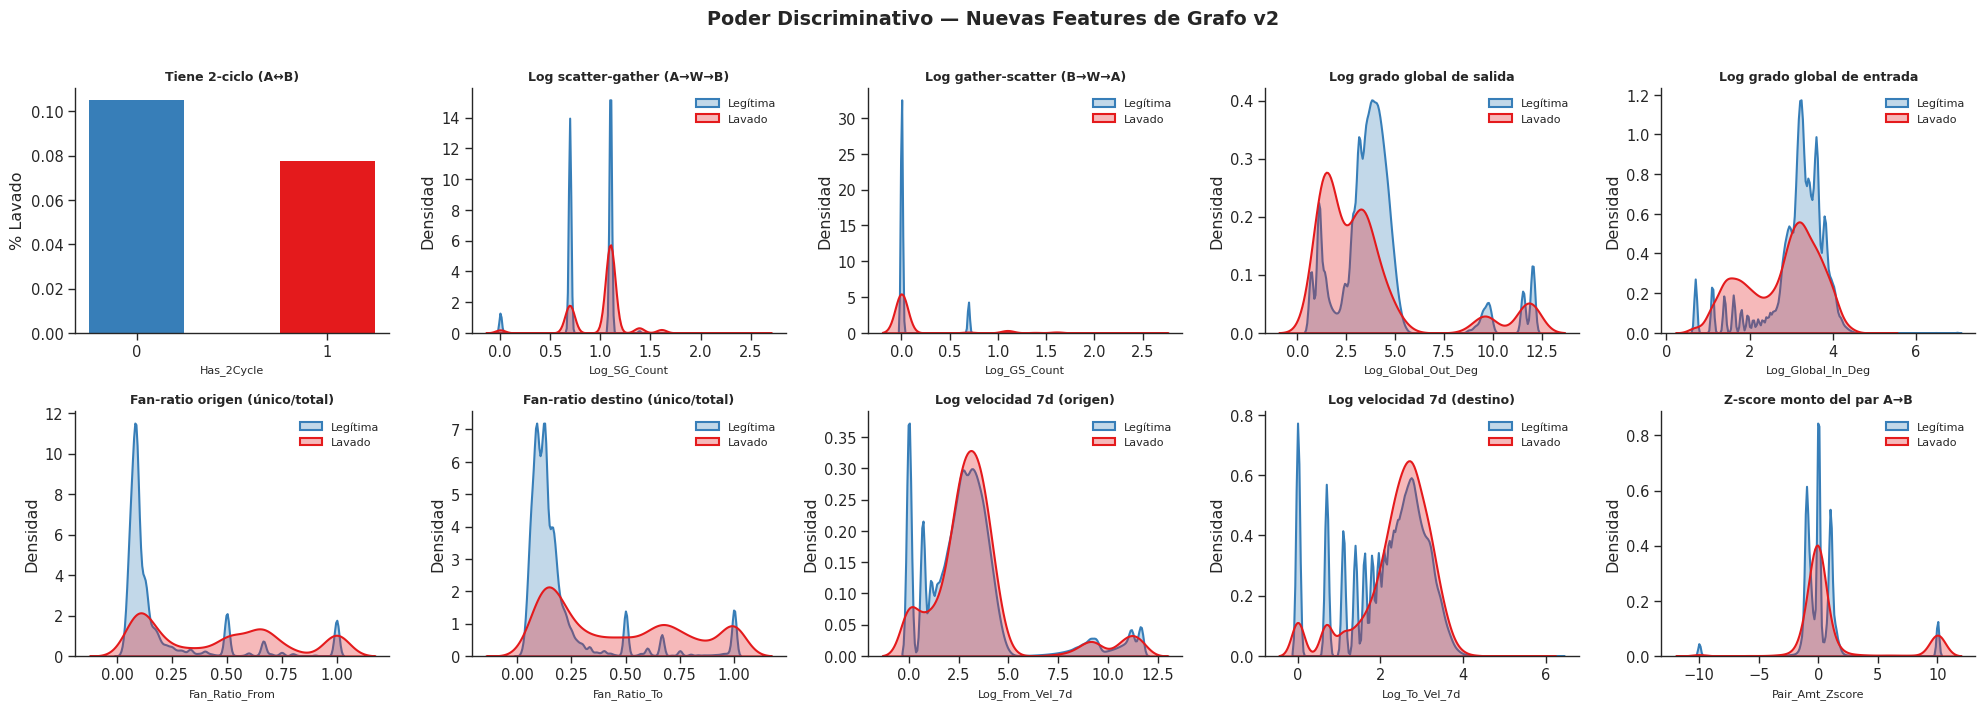

In [ ]:
GRAPH_ADV_FEATURES = [
    'Has_2Cycle',
    'Log_SG_Count',
    'Log_GS_Count',
    'Log_Global_Out_Deg',
    'Log_Global_In_Deg',
    'Fan_Ratio_From',
    'Fan_Ratio_To',
    'Log_From_Vel_7d',
    'Log_To_Vel_7d',
    'Pair_Hist_Count',
    'Pair_Amt_Zscore',
]

df_adv, new_cols = build_graph_features_advanced(df)

pipeline_output_v2 = build_features(df_adv)

X_v2 = pipeline_output_v2['X'].copy()
y_v2 = pipeline_output_v2['y']

for col in GRAPH_ADV_FEATURES:
    X_v2[col] = df_adv[col].values

print(f"Shape X_v2: {X_v2.shape}")
print(f"Features totales: {len(X_v2.columns)}")


In [ ]:
import time
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix

warnings.filterwarnings("ignore")


# ─────────────────────────────────────────────────────────────────────────────
# Utilidad de timing
# ─────────────────────────────────────────────────────────────────────────────

class _Timer:
    def __init__(self, msg: str):
        self.msg = msg

    def __enter__(self):
        print(f"   {self.msg}...", end=" ", flush=True)
        self._t = time.time()
        return self

    def __exit__(self, *_):
        print(f"✓  {time.time() - self._t:.1f}s")


# ─────────────────────────────────────────────────────────────────────────────
# Función principal
# ─────────────────────────────────────────────────────────────────────────────

def build_cycle_biclique_features(
    df: pd.DataFrame,
    src_col: str  = "Account",
    dst_col: str  = "Account.1",
    label_col: str = "Is Laundering",
    compute_c4: bool  = True,
    compute_bic: bool = True,
) -> tuple[pd.DataFrame, list[str]]:
    """
    Parámetros
    ----------
    df          : DataFrame con columnas Account, Account.1, Is Laundering
    compute_c4  : Si False, omite C4 (más rápido pero menos features)
    compute_bic : Si False, omite biclique K2,2

    Retorna
    -------
    (df_out, new_cols) donde df_out tiene las nuevas columnas
    y new_cols es la lista de nombres de features añadidas.
    """
    out = df.copy()
    src_arr = df[src_col].values
    dst_arr = df[dst_col].values
    m = len(src_arr)

    t_total = time.time()
    print("\n" + "═" * 60)
    print(" build_cycle_biclique_features()")
    print("═" * 60)

    # ── 1. Codificar nodos como enteros ──────────────────────────────────────
    with _Timer("Codificando nodos"):
        all_nodes = np.unique(np.concatenate([src_arr, dst_arr]))
        n = len(all_nodes)
        node2idx = {node: i for i, node in enumerate(all_nodes)}
        u_idx = np.fromiter((node2idx[u] for u in src_arr), dtype=np.int32, count=m)
        v_idx = np.fromiter((node2idx[v] for v in dst_arr), dtype=np.int32, count=m)
        print(f"\n       {n:,} nodos  |  {m:,} aristas (multigraph)")

    # ── 2. Matriz de adyacencia simple (sin multi-aristas) ───────────────────
    # Usamos el grafo simple subyacente para detectar *estructuras*;
    # las features de frecuencia ya están en el pipeline base.
    with _Timer("Construyendo A (grafo simple)"):
        edge_pairs = np.unique(np.stack([u_idx, v_idx], axis=1), axis=0)
        eu, ev = edge_pairs[:, 0], edge_pairs[:, 1]
        A = csr_matrix(
            (np.ones(len(eu), dtype=np.float32), (eu, ev)),
            shape=(n, n),
        )
        print(f"\n       A simple: {A.shape}, nnz={A.nnz:,}")

    # ── 3. Vecindarios como sets (para C3 y biclique) ─────────────────────────
    with _Timer("Construyendo vecindarios (sets)"):
        out_nbrs: dict[int, set] = {}
        in_nbrs:  dict[int, set] = {}
        for u, v in zip(eu.tolist(), ev.tolist()):
            out_nbrs.setdefault(u, set()).add(v)
            in_nbrs.setdefault(v, set()).add(u)

    # ── 4. C3 dirigido ────────────────────────────────────────────────────────
    # Para arista u→v:  C3 = |out(v) ∩ in(u)|
    # (caminos v→w→u cierran el triángulo u→v→w→u)
    with _Timer("C3 dirigido"):
        _empty: frozenset = frozenset()
        dir_c3 = np.array([
            len(out_nbrs.get(int(v), _empty) & in_nbrs.get(int(u), _empty))
            for u, v in zip(u_idx, v_idx)
        ], dtype=np.float32)

    # ── 5. C3 indirigido (triángulos) ─────────────────────────────────────────
    # A_und²[u,v] = nº de vecinos comunes en el grafo indirigido
    with _Timer("C3 indirigido (triangulos)"):
        A_und = A + A.T
        A_und.data[:] = 1.0           # binarizar pesos
        A_und = A_und.tocsr()
        A_und2 = A_und.dot(A_und)
        und_c3 = np.asarray(
            A_und2[u_idx, v_idx]
        ).flatten().astype(np.float32)

    # ── 6. C4 dirigido ────────────────────────────────────────────────────────
    # Para arista u→v:  C4 = Σ_{w ∈ out(v)} A²[w, u]
    # (equivale a A³[v,u] pero sin materializar A³ completo)
    # Estrategia: precalcular A², agrupar aristas por v, hacer sub-selección sparse.
    if compute_c4:
        with _Timer("Calculando A² (sparse matmul)"):
            A2 = A.dot(A).tocsr()
            print(f"\n       A²  nnz={A2.nnz:,}")

        with _Timer("C4 dirigido (batch por v)"):
            # Agrupar índices de aristas por nodo destino v
            edges_by_v: dict[int, list] = defaultdict(list)
            for i, (u, v) in enumerate(zip(u_idx.tolist(), v_idx.tolist())):
                edges_by_v[v].append((u, i))

            dir_c4 = np.zeros(m, dtype=np.float32)

            for v, pairs in edges_by_v.items():
                # out-neighbors of v en A (acceso directo al CSR)
                w_arr = A.indices[A.indptr[v]:A.indptr[v + 1]]
                if len(w_arr) == 0:
                    continue

                u_arr = np.array([p[0] for p in pairs], dtype=np.int32)
                idxs  = [p[1] for p in pairs]

                # sub[i,j] = A²[w_arr[i], u_arr[j]]  →  suma sobre filas = C4
                sub     = A2[w_arr, :][:, u_arr]
                c4_vals = np.asarray(sub.sum(axis=0)).flatten()
                dir_c4[idxs] = c4_vals
    else:
        dir_c4 = np.zeros(m, dtype=np.float32)
        print("   C4 dirigido  →  omitido (compute_c4=False)")

    # ── 7. Biclique K2,2 ──────────────────────────────────────────────────────
    # Para arista u→v:  bic_count = | {u2 ∈ in(v) \ {u} : out(u2) ∩ out(u) \ {v} ≠ ∅} |
    # i.e., nº de co-emisores hacia v que también comparten al menos un destino con u
    if compute_bic:
        with _Timer("Biclique K2,2 (set intersection por arista)"):
            # Pre-computar out(u) una vez por nodo único emisor
            unique_u = {int(u) for u in u_idx}
            out_u_cache = {u: out_nbrs.get(u, set()) for u in unique_u}

            bic_count = np.zeros(m, dtype=np.float32)
            for i, (u, v) in enumerate(zip(u_idx.tolist(), v_idx.tolist())):
                u_int = int(u)
                v_int = int(v)
                co_senders = in_nbrs.get(v_int, _empty) - {u_int}
                if not co_senders:
                    continue
                out_u_excl = out_u_cache[u_int] - {v_int}
                if not out_u_excl:
                    continue
                cnt = 0
                for u2 in co_senders:
                    if out_nbrs.get(u2, _empty) & out_u_excl:
                        cnt += 1
                bic_count[i] = cnt
    else:
        bic_count = np.zeros(m, dtype=np.float32)
        print("   Biclique K2,2 →  omitido (compute_bic=False)")

    # ── 8. Asignar columnas al DataFrame ──────────────────────────────────────
    out["Has_DirC3"]        = (dir_c3 > 0).astype("uint8")
    out["Log_DirC3_Count"]  = np.log1p(dir_c3).astype("float32")
    out["Has_DirC4"]        = (dir_c4 > 0).astype("uint8")
    out["Log_DirC4_Count"]  = np.log1p(dir_c4).astype("float32")
    out["Has_UndC3"]        = (und_c3 > 0).astype("uint8")
    out["Log_UndC3_Count"]  = np.log1p(und_c3).astype("float32")
    out["Has_Bic"]          = (bic_count > 0).astype("uint8")
    out["Log_Bic_Count"]    = np.log1p(bic_count).astype("float32")

    new_cols = [
        "Has_DirC3", "Log_DirC3_Count",
        "Has_DirC4", "Log_DirC4_Count",
        "Has_UndC3", "Log_UndC3_Count",
        "Has_Bic",   "Log_Bic_Count",
    ]

    # ── 9. Diagnóstico: poder discriminativo ──────────────────────────────────
    print(f"\n  {'Feature':<24} {'Rango':>16}   {'Lav/Leg':>8}   {'%Pos c/feature':>14}")
    print("  " + "─" * 68)
    label = out[label_col].values
    n_lav = label.sum()
    for f in new_cols:
        vals = out[f].values
        mn, mx     = vals.min(), vals.max()
        lav_m      = vals[label == 1].mean()
        leg_m      = vals[label == 0].mean()
        ratio      = lav_m / (leg_m + 1e-9)
        pos_with_f = (label[vals > 0] == 1).sum() / (n_lav + 1e-9)
        print(
            f"  {f:<24} [{mn:5.2f},{mx:7.1f}]"
            f"   {ratio:>8.2f}x"
            f"   {pos_with_f:>12.1%}"
        )

    print(f"\n  Tiempo total : {time.time() - t_total:.1f}s")
    print("═" * 60 + "\n")

    return out, new_cols


In [ ]:
df_cycles, CYCLE_COLS = build_cycle_biclique_features(
    df_adv,          # DataFrame que ya tiene las features del pipeline base
    compute_c4=True,
    compute_bic=True,
)

# ── Paso B: añadir al X_v2 existente ─────────────────────────────────────────
X_v3 = X_v2.copy()
for col in CYCLE_COLS:
    X_v3[col] = df_cycles[col].values

y_v3 = y_v2.copy()

print(f"Shape X_v3 ampliado: {X_v3.shape}")
print(f"Nuevas features: {CYCLE_COLS}")



════════════════════════════════════════════════════════════
 build_cycle_biclique_features()
════════════════════════════════════════════════════════════
   Codificando nodos... 
       515,080 nodos  |  5,078,336 aristas (multigraph)
✓  23.2s
   Construyendo A (grafo simple)... 
       A simple: (515080, 515080), nnz=1,015,736
✓  7.4s
   Construyendo vecindarios (sets)... ✓  3.2s
   C3 dirigido... ✓  8.7s
   C3 indirigido (triangulos)... ✓  20.1s
   Calculando A² (sparse matmul)... 
       A²  nnz=13,211,399
✓  0.3s
   C4 dirigido (batch por v)... ✓  306.1s
   Biclique K2,2 (set intersection por arista)... ✓  139.4s

  Feature                             Rango    Lav/Leg   %Pos c/feature
  ────────────────────────────────────────────────────────────────────
  Has_DirC3                [ 0.00,    1.0]       0.84x          10.0%
  Log_DirC3_Count          [ 0.00,    2.6]       1.40x          10.0%
  Has_DirC4                [ 0.00,    1.0]       0.92x          10.9%
  Log_DirC4_Count  

## 5. Division Train / Test Cronologica


In [ ]:
n       = len(df)
n_train = int(n * 0.8)

X_train, y_train = X.iloc[:n_train],  y.iloc[:n_train]
X_test,  y_test  = X.iloc[n_train:],  y.iloc[n_train:]

print(f"{'Conjunto':<12} {'Filas':>10} {'Lavado':>10} {'% Lavado':>10}")
print("-" * 44)
for name, ys in [('Train', y_train), ('Test', y_test)]:
    print(f"{name:<12} {len(ys):>10,} {ys.sum():>10,} {ys.mean()*100:>9.4f}%")

ts = pipeline_output['df_full']['Timestamp']
print(f"\nCortes temporales:")
print(f"  Train : {ts.iloc[0].date()} -> {ts.iloc[n_train-1].date()}")
print(f"  Test  : {ts.iloc[n_train].date()} -> {ts.iloc[-1].date()}")

# **Data Export**


In [ ]:
import os
import pandas as pd

def convert_sparse_to_dense(df):
    df_dense = df.copy()
    for col in df_dense.columns:
        if pd.api.types.is_sparse(df_dense[col]):
            df_dense[col] = df_dense[col].sparse.to_dense()
    return df_dense

def export_pipeline_datasets(X_dict, y_dict, base_path='/content/drive/MyDrive/Datasets/Final Project/Processed_Unified/'):
    os.makedirs(base_path, exist_ok=True)

    for version, X_data in X_dict.items():
        y_data = y_dict[version]

        # Division Train / Test (80/20 cronologico)
        n = len(X_data)
        n_train = int(n * 0.8)

        X_train_split = X_data.iloc[:n_train]
        X_test_split  = X_data.iloc[n_train:]
        y_train_split = y_data.iloc[:n_train]
        y_test_split  = y_data.iloc[n_train:]

        print(f"\n--- Exportando {version} ---")
        print(f"Train: {len(X_train_split):,} filas | Test: {len(X_test_split):,} filas")

        # Convertir a dense y exportar
        convert_sparse_to_dense(X_train_split).to_parquet(f'{base_path}X_train_{version}.parquet', index=False)
        convert_sparse_to_dense(X_test_split).to_parquet(f'{base_path}X_test_{version}.parquet', index=False)
        pd.DataFrame(y_train_split).to_parquet(f'{base_path}y_train_{version}.parquet', index=False)
        pd.DataFrame(y_test_split).to_parquet(f'{base_path}y_test_{version}.parquet', index=False)
        print(f"✓ {version} guardada exitosamente en {base_path}")

# Ejecucion consolidada:
datasets_X = {'v1': X, 'v2': X_v2, 'v3': X_v3}
datasets_y = {'v1': y, 'v2': y_v2, 'v3': y_v3}

export_pipeline_datasets(datasets_X, datasets_y)


## 7. Visualizacion de Nuevas Features


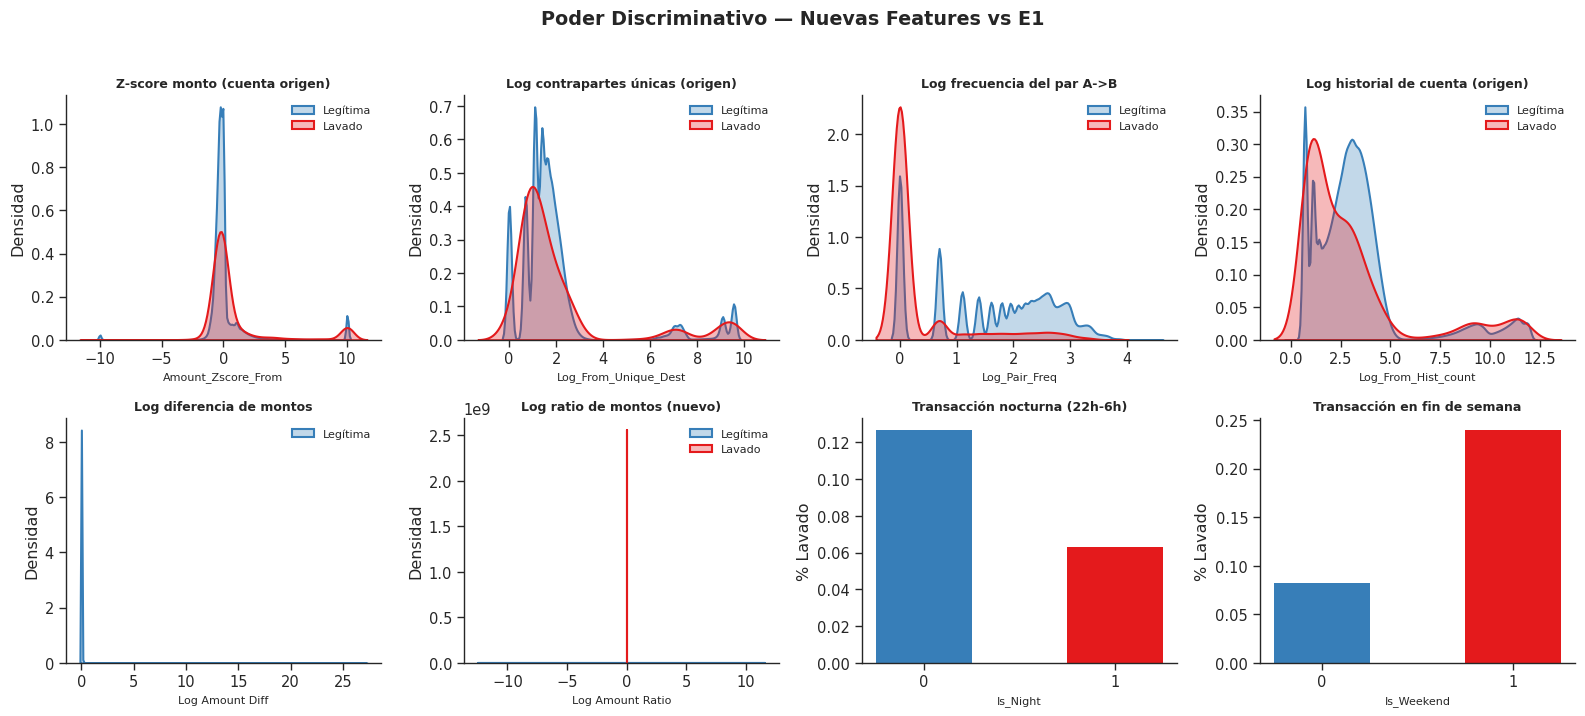

In [ ]:
df_full = pipeline_output['df_full']

features_to_plot = [
    ('Amount_Zscore_From',    'Z-score monto (cuenta origen)'),
    ('Log_From_Unique_Dest',  'Log contrapartes únicas (origen)'),
    ('Log_Pair_Freq',         'Log frecuencia del par A->B'),
    ('Log_From_Hist_count',   'Log historial de cuenta (origen)'),
    ('Log Amount Diff',       'Log diferencia de montos'),
    ('Log Amount Ratio',      'Log ratio de montos (nuevo)'),
    ('Is_Night',              'Transacción nocturna (22h-6h)'),
    ('Is_Weekend',            'Transacción en fin de semana'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

# Tomamos colores de la paleta por defecto de seaborn ('Set1')
colors = sns.color_palette()
c_legit = colors[1] # Azul (índice 1 en Set1)
c_fraud = colors[0] # Rojo (índice 0 en Set1)

for ax, (feat, title) in zip(axes, features_to_plot):
    legit_vals = df_full.loc[df_full['Is Laundering'] == 0, feat]
    fraud_vals = df_full.loc[df_full['Is Laundering'] == 1, feat]

    if df_full[feat].nunique() <= 2:
        rates = df_full.groupby(feat)['Is Laundering'].mean() * 100
        ax.bar(rates.index.astype(str), rates.values,
               color=[c_legit, c_fraud],
               edgecolor='none', width=0.5)
        ax.set_ylabel('% Lavado')
    else:
        sns.kdeplot(legit_vals, ax=ax, color=c_legit,
                    fill=True, alpha=0.3, linewidth=1.5, label='Legítima')
        sns.kdeplot(fraud_vals, ax=ax, color=c_fraud,
                    fill=True, alpha=0.3, linewidth=1.5, label='Lavado')
        ax.legend(frameon=False, fontsize=8)
        ax.set_ylabel('Densidad')

    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel(feat, fontsize=8)
    sns.despine(ax=ax)

fig.suptitle('Poder Discriminativo — Nuevas Features vs E1', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()